In [59]:
# https://github.com/rfsantacruz/cvx-nb/blob/master/DoublyStochasticApproximation.ipynb

# approximate dh-matrix
import numpy as np
import networkx as nx

from matplotlib import pyplot as plt
%matplotlib inline


def sinkhorn(X, max_it=10):
    Y = np.copy(X)
    for it in range(max_it):
        # Line multipliers normalizer
        D1 = np.diagflat(1. / np.sum(Y, axis=1))
        # Cols multipliers normalizer
        D2 = np.diagflat(1. / np.sum(np.dot(D1, Y), axis=0))
        # Normalize D1 Y D2
        Y = np.dot(np.dot(D1, Y),D2)
    return Y

X = np.random.rand(2,2)
Y = sinkhorn(X)
print("Random input:\n{}".format(X))
print("Sinkhorn Approx. DSM:\n{}".format(Y))



def generate_random_symmetric_doubly_stochastic_matrix(n, max_it = 10):
    # Generate a random matrix of size n x n
    matrix = np.random.rand(n, n)

    # Make the matrix symmetric
    matrix = (matrix + matrix.T) / 2
    # Normalize each column to sum up to 1
    wc = np.sqrt(np.sum(matrix, axis=0))
    matrix = matrix / wc
    matrix = matrix / wc[:, np.newaxis]
    matrix = sinkhorn(matrix,max_it=max_it)
    return matrix
n = 10
x = generate_random_symmetric_doubly_stochastic_matrix(n)
print(np.sum(x-np.transpose(x)))
print('row sum',np.sum(x,axis=0))
print('col sum',np.sum(x,axis=1))


def get_pagerank(matrix):
    graph = nx.from_numpy_array(matrix, create_using=nx.DiGraph)
    pagerank = nx.pagerank(graph)
    pr = np.array(list(pagerank.values()))
    return pr

pr = get_pagerank(matrix)
print('page rank: ', pr)

pr_rank = np.argsort(-pr)
print('rank wrt pagerank', pr_rank)
sim_rank = np.argsort(-np.sum(matrix,axis=0))
print('rank wrt pagerank', sim_rank)


n1 = pr_rank[:k]
n2 = sim_rank[:k]
print('n1, n2',n1,n2)



Random input:
[[0.55477541 0.00917532]
 [0.57030084 0.92816953]]
Sinkhorn Approx. DSM:
[[0.90583344 0.08904872]
 [0.09416656 0.91095128]]
0.0
row sum [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
col sum [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
page rank:  [0.30383867 0.29017848 0.40598286]
rank wrt pagerank [2 0 1]
rank wrt pagerank [2 0 1]
n1, n2 [2 0 1] [2 0 1]


top k is 2
(10,)


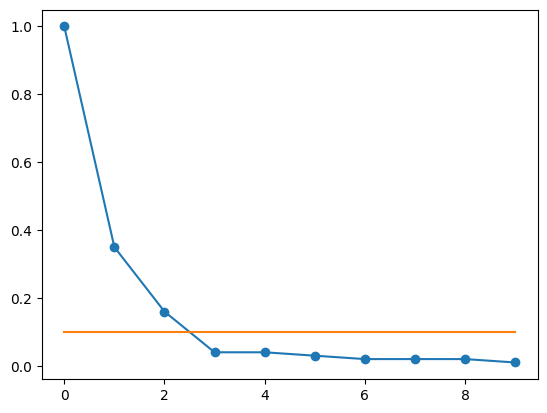

In [68]:
N = 100
n = 10
k = int(np.min([3,np.round(0.2*n)]))
print('top k is', k)
result = np.zeros((N,n))
for i in range(N):
    X = generate_random_symmetric_doubly_stochastic_matrix(n,max_it=20)
    pr = get_pagerank(X)
    pr_rank = np.argsort(-pr)
    sim_rank = np.argsort(-np.sum(X,axis=0))
    sim_rank = sim_rank.astype(int)
    pr_rank = pr_rank.astype(int)

    #print(sim_rank)
    #print(pr_rank)
    r = np.all(pr_rank == sim_rank)

    for k in range(n):
        n1 = pr_rank[:k]
        n2 = sim_rank[:k]
        r2 = np.all(n2 == n1)
        result[i,k]=r2
    #print(f'iter x: {i}, equal ranks: {r1}, {r}, top-k ranks {r2}')
    #result.append(r2)

#print(100*np.sum(np.array(result))/N)
#print(100*np.sum(np.array(result))/N)

mean_acc_by_k = np.mean(result, axis=0)
print(mean_acc_by_k.shape)
plt.plot(mean_acc_by_k,marker='o', linestyle='-')
plt.plot(pr)
    

In [71]:
pr
def generate_doubly_stochastic_matrix(n):
    # Generate a random matrix of size n x n
    matrix = np.random.rand(n, n)
    matrix = matrix / np.sum(matrix, axis=1)[:, np.newaxis]
    matrix = matrix / np.sum(matrix, axis=0)
    return matrix

new_matrix = generate_doubly_stochastic_matrix(n)
print(new_matrix)
new_matrix = np.ones((n, n)) / n
print(new_matrix)

[[0.02445177 0.21162709 0.06239765 0.09071541 0.04288914 0.17370781
  0.10539216 0.01049049 0.11327745 0.14607955]
 [0.07486439 0.08766909 0.00333724 0.09027734 0.25243491 0.01962905
  0.17021015 0.23054708 0.03134022 0.07891263]
 [0.11564823 0.0628567  0.22507904 0.10508168 0.13495434 0.07762967
  0.05393516 0.03030433 0.09012407 0.12328124]
 [0.07370109 0.0830484  0.09544722 0.10601392 0.0285365  0.11602282
  0.12357837 0.21809933 0.03819294 0.13401458]
 [0.15151811 0.01225928 0.03968571 0.03440933 0.1847578  0.14357797
  0.02521022 0.07188493 0.11423148 0.17949642]
 [0.09793491 0.06454349 0.20788808 0.09529894 0.0180115  0.08205361
  0.13051871 0.09691211 0.10936077 0.10859913]
 [0.09885095 0.15953443 0.05044521 0.11993416 0.1717517  0.08436244
  0.0891729  0.18473981 0.04152612 0.03728877]
 [0.09955894 0.04410749 0.18894616 0.18085147 0.0159479  0.09800722
  0.10923791 0.07959759 0.13544544 0.05449909]
 [0.15354593 0.22776028 0.06533913 0.04602603 0.03822926 0.04376391
  0.1546066 

In [73]:
import numpy as np

def generate_random_symmetric_doubly_stochastic_matrix(n):
    # Generate a random matrix of size n x n
    matrix = np.random.rand(n, n)

    matrix = (matrix + matrix.T) / 2

    row_sums = np.sum(matrix, axis=1)
    col_sums = np.sum(matrix, axis=0)

    matrix /= np.maximum(row_sums, col_sums)[:, np.newaxis]
    matrix = matrix / np.sum(matrix, axis=0)

    return matrix

n = 5  # Size of the matrix
matrix = generate_random_symmetric_doubly_stochastic_matrix(n)
print(matrix)
print(np.sum(matrix,axis=0))
print(np.sum(matrix,axis=1))



[[0.13497564 0.30151879 0.18229813 0.26785289 0.13428494]
 [0.2927742  0.22823658 0.14675887 0.09669389 0.21909977]
 [0.18351233 0.15214895 0.34839163 0.15068017 0.18286986]
 [0.25609461 0.09521047 0.14311237 0.30415806 0.17482364]
 [0.13264322 0.2228852  0.17943899 0.18061499 0.28892179]]
[1. 1. 1. 1. 1.]
[1.0209304  0.98356332 1.01760294 0.97339916 1.00450418]


In [ ]:
import numpy as np

def generate_random_doubly_stochastic_matrix(n):
    # Generate a random matrix of size n x n
    matrix = np.random.rand(n, n)

    # Normalize each row to sum up to 1
    matrix = matrix / np.sum(matrix, axis=1)[:, np.newaxis]

    # Normalize each column to sum up to 1
    matrix = matrix / np.sum(matrix, axis=0)

    return matrix

# Specify the size of the matrix
n = 5

# Generate a random doubly stochastic matrix
matrix = generate_random_doubly_stochastic_matrix(n)

print(matrix)